<a href="https://colab.research.google.com/github/trevorlillywhite/HW6_ST554_TrevorLillywhite/blob/main/Homework_6_ST_554_Trevor_Lillywhite.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 6 - ST 554
### **Author:** Trevor Lillywhite
#### **Due Date:** March 10, 2026

## Part I - More Practice Querying a Database

There is a database file on the assignment link called lahman_1871-2022.sqlite that is an sqlite database
downloaded from [here](https://github.com/jknecht/baseball-archive-sqlite). This database has information on Major League Baseball.

#### Question 1
**Instructions:** Connect to the database and then look at all of the tables in the database (use `read_sql()` from `pandas` to have this returned as a dataframe).

_Approach:_ Similar to last assignment, we will define a connection to the database (which was imported as a file into our environment) using the `sqlite3` module. Then, we will use `pandas` to read the SQLite file. The list of tables will be pulled using a standard `get_schema` query.

In [1]:
# Import relevant modules
import sqlite3
import pandas as pd

# Define the connection to the database
con = sqlite3.connect('lahman_1871-2022.sqlite')

In [2]:
# Define query to pull table schema
query_schema = '''
    SELECT *
    FROM sqlite_schema
    WHERE type = "table";
'''
# Create and display object with table schema
schema = pd.read_sql(query_schema, con)
schema

,type,name,tbl_name,rootpage,sql
0,table,AllstarFull,AllstarFull,2,"CREATE TABLE AllstarFull (\nplayerID TEXT,\nye..."
1,table,Appearances,Appearances,3,"CREATE TABLE Appearances (\nyearID INTEGER,\nt..."
2,table,AwardsManagers,AwardsManagers,4,"CREATE TABLE AwardsManagers (\nplayerID TEXT,\..."
3,table,AwardsPlayers,AwardsPlayers,5,"CREATE TABLE AwardsPlayers (\nplayerID TEXT,\n..."
4,table,AwardsShareManagers,AwardsShareManagers,6,CREATE TABLE AwardsShareManagers (\nawardID TE...
5,table,AwardsSharePlayers,AwardsSharePlayers,7,CREATE TABLE AwardsSharePlayers (\nawardID TEX...
6,table,Batting,Batting,8,"CREATE TABLE Batting (\nplayerID TEXT,\nyearID..."
7,table,BattingPost,BattingPost,9,"CREATE TABLE BattingPost (\nyearID INTEGER,\nr..."
8,table,CollegePlaying,CollegePlaying,10,"CREATE TABLE CollegePlaying (\nplayerID TEXT,\..."
9,table,Fielding,Fielding,11,"CREATE TABLE Fielding (\nplayerID TEXT,\nyearI..."


There are 27 tables included in the database. They include data about players, managers, teams, awards, and more.

#### Question 2
**Instructions:** Using SQL, construct a table of hall of fame pitchers (any hall of famer that pitched) that gives the `playerID` and their total (sum) for `GS`, `G`, `W`, `L`, `IPOuts`, `CG`, `SHO`, and `SV` columns. The summing can be done in `pandas` or in the SQL call.

_Approach:_ It looks like the `HallOfFame` table is most relevant. We will initially pull a couple example rows from this table to verify whether it contains the information we need. Otherwise, we will need to find the correct columns and do a `JOIN` with other table(s) if they are not located in a single table. After we confirm the contents of the table(s) we need, we will create a new query to call just the information we want.

In [3]:
# Define query to take a peek at the HallOfFame table
query_peek_HOF = '''
    SELECT *
    FROM HallOfFame
    LIMIT 2
'''

# Execute query and save results to an object
peek_HOF = pd.read_sql(query_peek_HOF, con)
peek_HOF

,playerID,yearid,votedBy,ballots,needed,votes,inducted,category,needed_note
0,aaronha01,1982,BBWAA,415,312,406,Y,Player,None
1,abbotji01,2005,BBWAA,516,387,13,N,Player,None


This table contains the `playerID` but none of the other stats we need. Let's explore some other tables to see where this data is saved. We will start with the `Pitching` table because we know we are only considering Hall of Famers who pitched.

In [4]:
# Define query to take a peek at the Pitching table
query_peek_Pitching = '''
    SELECT *
    FROM Pitching
    LIMIT 2
'''

# Execute query and save results to an object
peek_Pitching = pd.read_sql(query_peek_Pitching, con)
peek_Pitching

,playerID,yearID,stint,teamID,lgID,W,L,G,GS,CG,...,IBB,WP,HBP,BK,BFP,GF,R,SH,SF,GIDP
0,aardsda01,2004,1,SFN,NL,1,0,11,0,0,...,0,0,2,0,61,5,8,0,1,1
1,aardsda01,2006,1,CHN,NL,3,0,45,0,0,...,0,1,1,0,225,9,25,1,3,2


Although there were too many columns to be displayed all at once (30), we see that we can identify all of the players who pitched (in the regular season) and most, if not all, of the stats we care about. Let's try querying everything we care about to see if it exists in this table or if we get an error (prompting us to look elsewhere).

In [5]:
# Define query to look for the subset of columns we need
query_subset_Pitching = '''
    SELECT playerID, GS, G, W, L, IPOuts, CG, SHO, SV
    FROM Pitching
    LIMIT 5
'''

# Execute query and display results
subset_Pitching = pd.read_sql(query_subset_Pitching, con)
subset_Pitching

,playerID,GS,G,W,L,IPouts,CG,SHO,SV
0,aardsda01,0,11,1,0,32,0,0,0
1,aardsda01,0,45,3,0,159,0,0,0
2,aardsda01,0,25,2,1,97,0,0,0
3,aardsda01,0,47,4,2,146,0,0,0
4,aardsda01,0,73,3,6,214,0,0,38


Now that we found the data we need, we need to determine our strategy for reaching the desired end result. If we created a single SQL query, we would be faced with performing a `UNION` or `UNION ALL` between the `Pitching` and `PitchingPost` tables, aggregating the desired statistics, and then doing a `WHERE` filter with the Hall of Famers, all without losing information in the unions, filters, and aggregation. This sounds more tedious than using Pandas to process the data.

Our strategy will be to pull the desired raw data from the `Pitching` and `PitchingPost` tables (each filtered by people listed in the `HallOfFame` table using the `WHERE` clause to cut down on the number of rows returned), stack the two tables vertically, and aggregate to find the total (summed) statistics over each pitcher's career.

In [6]:
# Define query to pull regular season stats for Hall of Fame pitchers
query_HOF_Pitching_stats = '''
    SELECT p.playerID, p.GS, p.G, p.W, p.L, p.IPOuts, p.CG, p.SHO, p.SV
    FROM Pitching AS p
    WHERE p.playerID IN (
        SELECT DISTINCT playerID
        FROM HallofFame
    )
'''

# Execute Query
df_HOF_Pitching = pd.read_sql(query_HOF_Pitching_stats, con)
df_HOF_Pitching

,playerID,GS,G,W,L,IPouts,CG,SHO,SV
0,abbotji01,29,29,12,12,544,4,2,0
1,abbotji01,33,33,10,14,635,4,1,0
2,abbotji01,34,34,18,11,729,5,1,0
3,abbotji01,29,29,7,15,633,7,0,0
4,abbotji01,32,32,11,14,642,4,1,0
...,...,...,...,...,...,...,...,...,...
7107,zitoba01,33,34,9,14,598,1,0,0
7108,zitoba01,9,13,3,4,161,0,0,0
7109,zitoba01,32,32,15,8,553,1,1,0
7110,zitoba01,25,30,5,11,400,0,0,0


In [7]:
# Repeat for post season
query_HOF_PitchingPost_stats = '''
    SELECT p.playerID, p.GS, p.G, p.W, p.L, p.IPOuts, p.CG, p.SHO, p.SV
    FROM PitchingPost AS p
    WHERE p.playerID IN (
        SELECT DISTINCT playerID
        FROM HallofFame
    )
'''

# Execute Query
df_HOF_PitchingPost = pd.read_sql(query_HOF_PitchingPost_stats, con)
df_HOF_PitchingPost

,playerID,GS,G,W,L,IPouts,CG,SHO,SV
0,adamsba01,3,3,3,0,81,3,1,0
1,adamsba01,0,1,0,0,3,0,0,0
2,aguilri01,0,2,0,0,15,0,0,0
3,aguilri01,0,2,1,0,9,0,0,0
4,aguilri01,0,3,0,0,21,0,0,0
...,...,...,...,...,...,...,...,...,...
1677,zitoba01,1,1,0,1,11,0,0,0
1678,zitoba01,1,1,1,0,24,0,0,0
1679,zitoba01,1,1,1,0,23,0,0,0
1680,zitoba01,1,1,0,0,8,0,0,0


The Post Season statistics table is much smaller than the regular season statistics table, which makes sense because these pitchers likely didn't make it to the post season every single year they pitched.

Now we can combine and aggregate these tables using `pandas`.

In [8]:
# Stack tables
df_HOF_Pitchers_RegAndPost = pd.concat([df_HOF_Pitching,
                                        df_HOF_PitchingPost],
                                       axis=0)
df_HOF_Pitchers_RegAndPost

,playerID,GS,G,W,L,IPouts,CG,SHO,SV
0,abbotji01,29,29,12,12,544,4,2,0
1,abbotji01,33,33,10,14,635,4,1,0
2,abbotji01,34,34,18,11,729,5,1,0
3,abbotji01,29,29,7,15,633,7,0,0
4,abbotji01,32,32,11,14,642,4,1,0
...,...,...,...,...,...,...,...,...,...
1677,zitoba01,1,1,0,1,11,0,0,0
1678,zitoba01,1,1,1,0,24,0,0,0
1679,zitoba01,1,1,1,0,23,0,0,0
1680,zitoba01,1,1,0,0,8,0,0,0


The tables were combined correctly. Now we will aggregate by grouping the `playerID` and summing.

In [9]:
df_HOF_Pitchers_RegAndPost = df_HOF_Pitchers_RegAndPost \
    .groupby('playerID', as_index=False) \
    .sum()
df_HOF_Pitchers_RegAndPost

,playerID,GS,G,W,L,IPouts,CG,SHO,SV
0,abbotji01,254,263,87,108,5022,31,6,0
1,adamsba01,358,486,197,140,9070,209,45,15
2,aguilri01,89,747,88,82,3946,10,0,323
3,akerja01,0,495,47,45,2238,0,0,123
4,alexado01,470,567,194,179,10190,98,18,3
...,...,...,...,...,...,...,...,...,...
522,zachrpa01,156,297,71,67,3579,29,7,3
523,zahnge01,271,305,111,110,5558,79,20,1
524,zambrca01,307,359,132,93,5964,10,5,0
525,zeileto01,0,2,0,0,6,0,0,0


Here, we have our final result showing each Hall of Famer who was a pitcher, along with their regular and post season stats summed together.

Because there are so few rows left, it is evident that the original Pitching table was broken into rows for more than just each year and regular/post season for each player (e.g., extra rows if the player switched teams mid-season).

#### Question 3
**Instructions:** For all of the hall of fame pitchers, use SQL to create a table of their batting statistics. Namely, the `playerID` and their total (sum) for `AB`, `R`, `H`, `HR`, `RBI`, `BB`, and `SO`. The summing can be done in pandas or in the SQL call.

_Approach:_ This task is very similar to the previous task. We will use the same method as before, but using fewer intermediate check steps since we proved out our method. We will separately filter the pitcher statistics for regular and post seasons by player inclusion in the `HallOfFame` table, and then we will combine and aggregate the results using `pandas`.

One difference is that we also need to consider the `Batting` or `BattingPost` tables alongside `Pitching` and `HallOfFame`. We will filter the Batting statistics based on whether the `playerID` is in both `HallOfFame` and `Pitching`.

In [10]:
# Define query to pull regular season batting stats for Hall of Fame pitchers
query_HOF_Batting_stats = '''
    SELECT b.playerID, b.AB, b.R, b.H, b.HR, b.RBI, b.BB, b.SO
    FROM Batting AS b
    WHERE b.playerID IN (
        SELECT DISTINCT h.playerID
        FROM HallOfFame AS h
        INNER JOIN Pitching AS p ON h.playerID = p.playerID
    )
'''

# Execute Query
df_HOF_Batting = pd.read_sql(query_HOF_Batting_stats, con)
df_HOF_Batting

,playerID,AB,R,H,HR,RBI,BB,SO
0,abbotji01,0,0,0,0,0.0,0,0.0
1,abbotji01,0,0,0,0,0.0,0,0.0
2,abbotji01,0,0,0,0,0.0,0,0.0
3,abbotji01,0,0,0,0,0.0,0,0.0
4,abbotji01,0,0,0,0,0.0,0,0.0
...,...,...,...,...,...,...,...,...
8458,zitoba01,51,1,6,0,2.0,1,17.0
8459,zitoba01,13,0,0,0,0.0,1,5.0
8460,zitoba01,53,3,4,0,2.0,6,12.0
8461,zitoba01,34,3,5,0,2.0,0,8.0


In [11]:
# Repeat for post season
query_HOF_BattingPost_stats = '''
    SELECT b.playerID, b.AB, b.R, b.H, b.HR, b.RBI, b.BB, b.SO
    FROM BattingPost AS b
    WHERE b.playerID IN (
        SELECT DISTINCT h.playerID
        FROM HallOfFame AS h
        INNER JOIN Pitching AS p ON h.playerID = p.playerID
    )
'''

# Execute Query
df_HOF_BattingPost = pd.read_sql(query_HOF_BattingPost_stats, con)
df_HOF_BattingPost

,playerID,AB,R,H,HR,RBI,BB,SO
0,adamsba01,9,0,0,0,0,1,1
1,adamsba01,0,0,0,0,0,0,0
2,aguilri01,0,0,0,0,0,0,0
3,aguilri01,0,0,0,0,0,0,0
4,aguilri01,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...
1956,zitoba01,0,0,0,0,0,0,0
1957,zitoba01,0,0,0,0,0,0,0
1958,zitoba01,2,0,1,0,1,0,1
1959,zitoba01,1,0,0,0,0,0,0


In [12]:
# Stack tables and aggregate
df_HOF_Batting_RegAndPost = pd.concat([df_HOF_Batting,
                                       df_HOF_BattingPost],
                                      axis=0) \
                                .groupby('playerID', as_index=False) \
                                .sum()
df_HOF_Batting_RegAndPost

,playerID,AB,R,H,HR,RBI,BB,SO
0,abbotji01,21,0,2,0,3.0,0,10.0
1,adamsba01,1028,79,216,3,75.0,54,195.0
2,aguilri01,141,12,28,3,11.0,6,38.0
3,akerja01,92,3,7,0,4.0,1,51.0
4,alexado01,265,19,44,0,17.0,9,77.0
...,...,...,...,...,...,...,...,...
522,zachrpa01,319,9,36,0,6.0,14,128.0
523,zahnge01,43,3,6,0,1.0,0,9.0
524,zambrca01,703,75,166,24,71.0,11,246.0
525,zeileto01,7686,993,2037,257,1124.0,958,1300.0


It appears we found the total batting statistics for the same group of 527 Hall of Famers who pitched at some point in their careers.

#### Question 4
**Instructions:** Using `pandas` join the previous two tables together by pitcher. (If you want, try to do all of this via
SQL! Not required though, feel free to use `pd.merge()` if you’d like)

_Approach:_ We will approach this using `pandas` for simplicity. We have our two data tables and need to use `pd.merge()` to combine them. Our final result should have the same number of rows and the sum of the number of columns (minus one since we don't need to repeat `playerID`).

In [13]:
# Create new table merging the two previous results
df_combined = pd.merge(df_HOF_Pitchers_RegAndPost,
                       df_HOF_Batting_RegAndPost,
                       'inner', 'playerID')
df_combined

,playerID,GS,G,W,L,IPouts,CG,SHO,SV,AB,R,H,HR,RBI,BB,SO
0,abbotji01,254,263,87,108,5022,31,6,0,21,0,2,0,3.0,0,10.0
1,adamsba01,358,486,197,140,9070,209,45,15,1028,79,216,3,75.0,54,195.0
2,aguilri01,89,747,88,82,3946,10,0,323,141,12,28,3,11.0,6,38.0
3,akerja01,0,495,47,45,2238,0,0,123,92,3,7,0,4.0,1,51.0
4,alexado01,470,567,194,179,10190,98,18,3,265,19,44,0,17.0,9,77.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
522,zachrpa01,156,297,71,67,3579,29,7,3,319,9,36,0,6.0,14,128.0
523,zahnge01,271,305,111,110,5558,79,20,1,43,3,6,0,1.0,0,9.0
524,zambrca01,307,359,132,93,5964,10,5,0,703,75,166,24,71.0,11,246.0
525,zeileto01,0,2,0,0,6,0,0,0,7686,993,2037,257,1124.0,958,1300.0


Success! The resulting table is the right shape, and it looks like all of the columns and rows were merged successfully (based on what is seen in the preview above).

## Part II - Messing with Classes

#### Question 5
**Instructions:** In the previous homework we used a loop to repeatedly do simulations around the estimate of a sample
slope. The setup was:
+ Recall we assume the following model for SLR:
    - $Y_i = β_0 + β_1x_i + E_i$

    where the $E_i$ are assumed to be indendent and identically distributed from a Normal distribution with mean 0 and variance $σ^2$. Let's assume $σ^2 = 1$ for simplicity.
+ We can generate data from this model by assuming values for $β_0$, $β_1$, and $n$, along with a sequence of $x$ values.

    _[The code to complete that part was provided, but omitted here for brevity.]_

Instead of writing this simulation in this way, we’ll design a Python class that encapsulates the simulation of the sampling distribution of the slope estimator!

Create a class called `SLR_slope_simulator`:
+ Initialize the class using `__init__` with arguments of `self`, `beta_0`, `beta_1`, `x`, `sigma`, and `seed`
    - Create initial attributes of `beta_0`, `beta_1`, `sigma`, `x`, `n`, `rng`, and `slopes` (an empty list)

+ Required Methods: Your class should include methods (not `@classmethod`, just methods that work on an already created instances of the class):
    - `generate_data` method that generates one dataset (returning `x` and `y` in whatever manner you deem fit, i.e. as an array, two arrays, etc.)
    - `fit_slope` method that takes in an `x` and `y` and fits the SLR model, returning the estimated slope
    - `run_simulations` method that takes in a number of simulations argument and uses the `generate_data()` and `fit_slope()` methods within a for loop. This should not return anything but should modify the slopes attribute (replaces it with an array of slope estimates)
    - `plot_sampling_distribution` method that checks if the `slopes` attribute has length greater than 0 (if it doesn’t print a message that `run_simulations()` must be called first). If it is, it should produce a histogram of the slopes approximating the sampling distribution.
    - `find_prob` method that takes in a `value` and a `sided` argument. It should checks on the `slopes` attribute as above. If the length is bigger than 0, it should approximate the probability of being “above”, “below”, or “two-sided” (values for `sided`).
        - If `sided` is "above", you should approximate the probability of being larger than the `value`.
        - If it is “below”, you should approximate the probability of being smaller than the `value`.
        - If it is “two-sided”, you should check if the `value` is above or below the median. If above, you should find two times the probability of being larger, if below, you should find two times the probability of being smaller.

**Results:** The class and test cases were written and are included in the `HW6_Part2_Lillywhite.py` file (loaded into the notebook environment for testing).

Create an instance with specified arguments



Call plot_sampling_distribution() - should return an error message
You can't do that! Call run_simulations() first.



Run 10,000 simulations



Plot the sampling distribution


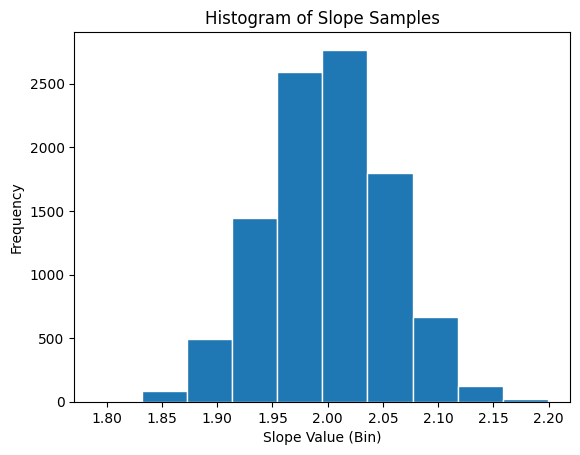




Approximate the two-sided probability of being larger than 2.1
0.0704



Print out simulated slopes using the object attribute
[np.float64(2.023916802504358), np.float64(1.9956055116302724), np.float64(2.0424909282886214), np.float64(1.964896413380284), np.float64(2.01114234679156), np.float64(1.9862612119146508), np.float64(2.0344380293191455), np.float64(2.08981268148745), np.float64(2.0169186811646767), np.float64(1.9117993672267974), np.float64(2.072305317362537), np.float64(2.008456465741332), np.float64(2.0812122404366296), np.float64(2.0474343500666654), np.float64(1.9868165439766214), np.float64(2.1036180116113665), np.float64(2.0312781657105576), np.float64(1.9193031597528145), np.float64(1.9872542366577477), np.float64(1.9593570244113567), np.float64(2.006906893211837), np.float64(2.0968216022658095), np.float64(2.094550044936993), np.float64(1.945219930956409), np.float64(1.9383848612910535), np.float64(2.0190264430482796), np.float64(2.0885766686790426), np.float64(2.071

In [16]:
# Import the module and reload it to pick up the latest changes
import HW6_Part2_Lillywhite

# Call the main() function to run test cases
HW6_Part2_Lillywhite.main()

The code tests all ran successfully! Each result seems reasonable.